# **Load data and flatten reviews**

In [1]:
import json
import re
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

CLEANED_FILE = Path("/kaggle/input/datasets/ahsanrizvimeow/amazon-product-intelligence-cleaned/products_cleaned.json")
with open(CLEANED_FILE, encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame(data)

rows = []
for _, p in df.iterrows():
    for r in p["reviews"]:
        rows.append({
            "asin": p["asin"],
            "category": p["search_keyword"],
            "product_title": p["title"],
            "rating_text": r.get("rating", ""),
            "review_title": r.get("title", ""),
            "body": r.get("body", ""),
            "body_en": r.get("body_en", r.get("body", "")),
            "verified": r.get("verified_purchase", False),
        })

rdf = pd.DataFrame(rows)

def parse_rating(t):
    m = re.search(r"([\d.]+)\s*out of 5", str(t))
    return float(m.group(1)) if m else None

rdf["rating"] = rdf["rating_text"].apply(parse_rating)
rdf["body_len"] = rdf["body_en"].str.len()

print(f"Total reviews: {len(rdf)}")
print(f"With parseable rating: {rdf['rating'].notna().sum()}")
print(f"With empty body: {(rdf['body_en'].str.strip() == '').sum()}")
display(rdf.head())

Total reviews: 11288
With parseable rating: 11288
With empty body: 6


,asin,category,product_title,rating_text,review_title,body,body_en,verified,rating,body_len
0,B0D2HJDH94,wireless earbuds,"Wireless Bluetooth 5.4 Earbuds, LED Power Disp...",5 out of 5 stars,Great Wireless Earbuds with Long Battery Life!,I really love these wireless earbuds! They con...,I really love these wireless earbuds! They con...,True,5.0,305
1,B0D2HJDH94,wireless earbuds,"Wireless Bluetooth 5.4 Earbuds, LED Power Disp...",5 out of 5 stars,Perfect option,Works great! I love how compact they are. And ...,Works great! I love how compact they are. And ...,True,5.0,571
2,B0D2HJDH94,wireless earbuds,"Wireless Bluetooth 5.4 Earbuds, LED Power Disp...",5 out of 5 stars,Excellent Product.,Excellent Earbuds. This is a long-term review....,Excellent Earbuds. This is a long-term review....,True,5.0,1546
3,B0D2HJDH94,wireless earbuds,"Wireless Bluetooth 5.4 Earbuds, LED Power Disp...",4 out of 5 stars,Good quality.,Good quality sound. Doesn’t hurt my ears. I li...,Good quality sound. Doesn’t hurt my ears. I li...,True,4.0,662
4,B0D2HJDH94,wireless earbuds,"Wireless Bluetooth 5.4 Earbuds, LED Power Disp...",5 out of 5 stars,I highly recommend this product inexpensive an...,I have purchased about six of these just becau...,I have purchased about six of these just becau...,True,5.0,560


# **EDA — rating distribution and class balance**

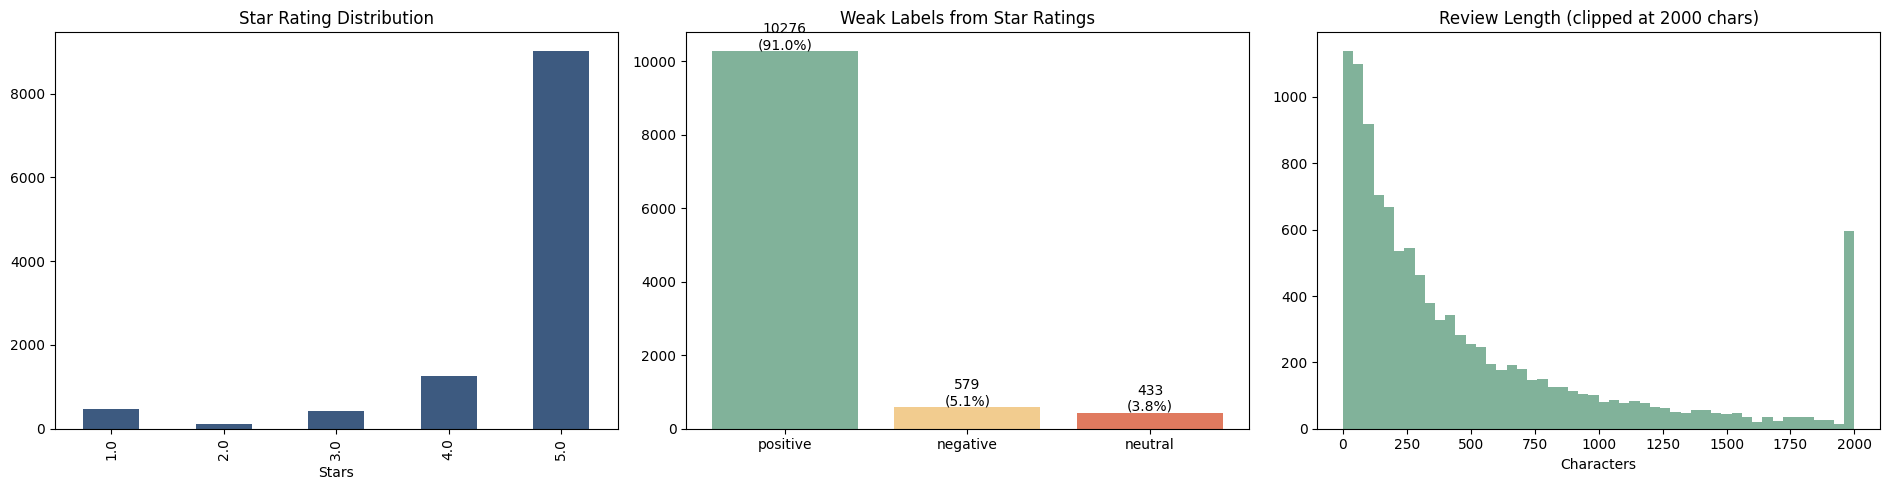

CLASS BALANCE


sentiment_weak
positive    91.0
negative     5.1
neutral      3.8
Name: proportion, dtype: float64


Sentiment mix by category (top 10 by review count):


sentiment_weak,negative,neutral,positive
category,,,
coffee maker,12.1,4.2,83.7
desk lamp LED,2.7,3.4,94.0
electric toothbrush,8.0,3.3,88.7
kitchen knife set,3.7,3.2,93.2
notebook journal,2.4,2.1,95.5
sneakers,3.1,6.3,90.6
sunglasses,4.2,6.1,89.8
t-shirt,4.0,6.3,89.7
water bottle,2.2,2.0,95.8


In [2]:
def rating_to_sentiment(rating):
    if pd.isna(rating):
        return None
    if rating >= 4:
        return "positive"
    if rating == 3:
        return "neutral"
    return "negative"

rdf["sentiment_weak"] = rdf["rating"].apply(rating_to_sentiment)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

rdf["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#3d5a80")
axes[0].set_title("Star Rating Distribution")
axes[0].set_xlabel("Stars")

sent_counts = rdf["sentiment_weak"].value_counts()
axes[1].bar(sent_counts.index, sent_counts.values,
            color=["#81b29a", "#f2cc8f", "#e07a5f"])
axes[1].set_title("Weak Labels from Star Ratings")
for i, v in enumerate(sent_counts.values):
    axes[1].text(i, v + 50, f"{v}\n({v/len(rdf)*100:.1f}%)", ha="center")

axes[2].hist(rdf["body_len"].clip(upper=2000), bins=50, color="#81b29a")
axes[2].set_title("Review Length (clipped at 2000 chars)")
axes[2].set_xlabel("Characters")

plt.tight_layout()
plt.show()

print("=" * 60)
print("CLASS BALANCE")
print("=" * 60)
display(rdf["sentiment_weak"].value_counts(normalize=True).mul(100).round(1))

print("\nSentiment mix by category (top 10 by review count):")
top_cats = rdf["category"].value_counts().head(10).index
ct = pd.crosstab(rdf[rdf["category"].isin(top_cats)]["category"],
                 rdf[rdf["category"].isin(top_cats)]["sentiment_weak"],
                 normalize="index").mul(100).round(1)
display(ct)

Original reviews: 11288
Reviews after dropping empty bodies: 11282
Removed: 6

Manual labelling sample: 180


/tmp/ipykernel_58/3920628157.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,weak_label,count
0,negative,60
1,neutral,60
2,positive,60


Saved: /kaggle/working/sentiment_manual_labels.csv
DEVICE INFORMATION
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.7 MB/s eta 0:00:00
VADER PREDICTION DISTRIBUTION


,sentiment,percentage
0,positive,90.16
1,negative,5.39
2,neutral,4.45


...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

TRANSFORMER READY
Running transformer inference on GPU
Reviews sent through transformer: 2000
Transformer batch size: 32
TRANSFORMER PREDICTION DISTRIBUTION


,sentiment,percentage
0,positive,83.55
1,negative,8.35
2,neutral,8.10


MODEL COMPARISON


,model,accuracy,macro_f1,negative_f1,neutral_f1,positive_f1
0,LogReg (balanced),0.934,0.790,0.751,0.654,0.964
1,Transformer,0.857,0.531,0.536,0.123,0.932
2,VADER,0.884,0.503,0.495,0.069,0.944


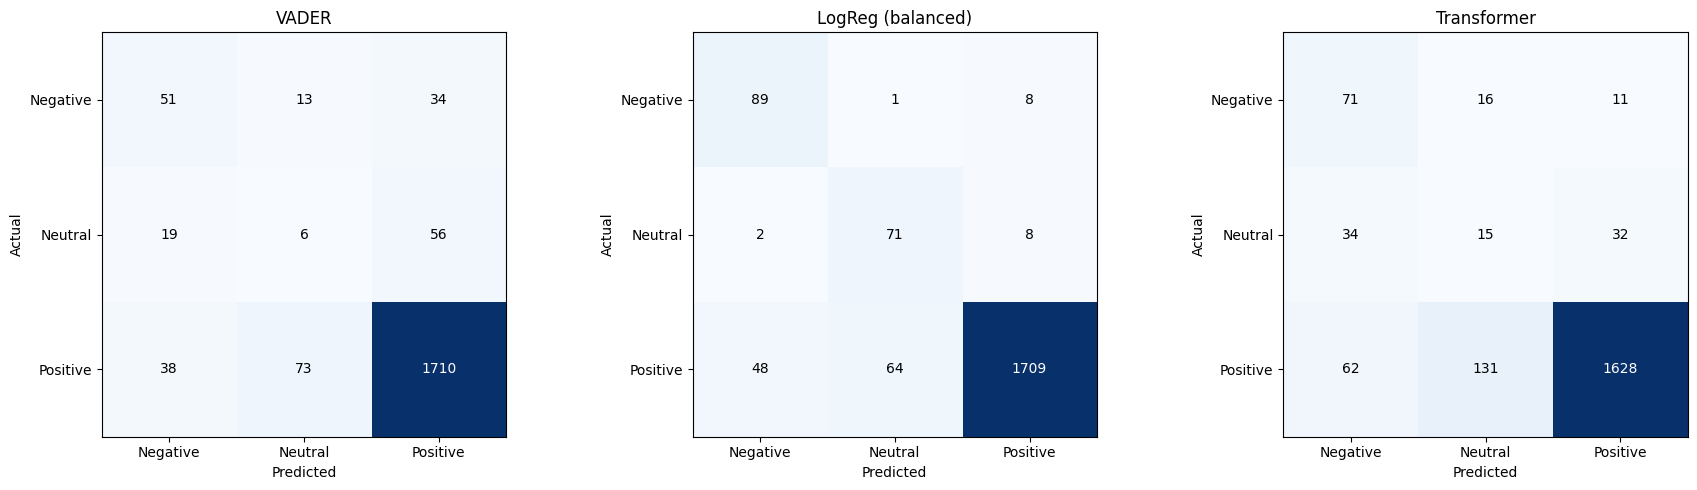

TRANSFORMER vs WEAK LABELS
              precision    recall  f1-score   support

    negative      0.425     0.724     0.536        98
     neutral      0.093     0.185     0.123        81
    positive      0.974     0.894     0.932      1821

    accuracy                          0.857      2000
   macro avg      0.497     0.601     0.531      2000
weighted avg      0.912     0.857     0.880      2000

CLASS WEIGHTING COMPARISON


,model,accuracy,macro_f1,negative_f1,neutral_f1,positive_f1
0,Unweighted,0.92,0.429,0.329,0.000,0.958
1,Class Weighted,0.90,0.614,0.557,0.333,0.952


Saved:
  /kaggle/working/sentiment_model/tfidf_vectorizer.joblib
  /kaggle/working/sentiment_model/sentiment_logistic_regression.joblib


In [3]:
# ============================================================
# CELL: Prepare data and create manual evaluation sample
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

# Keep only reviews with usable English text
rdf_clean = rdf[
    rdf["body_en"].notna() &
    rdf["body_en"].str.strip().ne("")
].reset_index(drop=True)

print(f"Original reviews: {len(rdf)}")
print(f"Reviews after dropping empty bodies: {len(rdf_clean)}")
print(f"Removed: {len(rdf) - len(rdf_clean)}")

# ------------------------------------------------------------
# Build balanced manual evaluation sample
# ------------------------------------------------------------

manual_sample = (
    rdf_clean
    .groupby("sentiment_weak", group_keys=False)
    .apply(
        lambda g: g.sample(
            n=min(60, len(g)),
            random_state=42
        )
    )
    .reset_index(drop=True)
)

print(f"\nManual labelling sample: {len(manual_sample)}")
display(
    manual_sample["sentiment_weak"]
    .value_counts()
    .rename_axis("weak_label")
    .reset_index(name="count")
)

manual_out = manual_sample[
    [
        "asin",
        "category",
        "rating",
        "review_title",
        "body_en",
        "sentiment_weak"
    ]
].copy()

manual_out["manual_label"] = ""

manual_path = "/kaggle/working/sentiment_manual_labels.csv"
manual_out.to_csv(manual_path, index=False)

print(f"Saved: {manual_path}")


# ============================================================
# CELL: Detect GPU
# ============================================================

import torch

print("=" * 70)
print("DEVICE INFORMATION")
print("=" * 70)

cuda_available = torch.cuda.is_available()

print("CUDA available:", cuda_available)

if cuda_available:
    device = 0
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )
else:
    device = -1
    print("GPU not available. Transformer will use CPU.")

print("=" * 70)


# ============================================================
# CELL: Baseline 1 — VADER
# ============================================================

# Install only if needed
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    !pip install vaderSentiment -q
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()


def vader_sentiment(text):
    score = vader.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"


rdf_clean["pred_vader"] = rdf_clean["body_en"].map(vader_sentiment)

print("=" * 70)
print("VADER PREDICTION DISTRIBUTION")
print("=" * 70)

display(
    rdf_clean["pred_vader"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("sentiment")
    .reset_index(name="percentage")
)


# ============================================================
# CELL: Baseline 2 — TF-IDF + Logistic Regression
# ============================================================

X = rdf_clean["body_en"]
y = rdf_clean["sentiment_weak"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("sentiment")
    .reset_index(name="percentage")
)


# ------------------------------------------------------------
# TF-IDF
# ------------------------------------------------------------

vec = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_v = vec.fit_transform(X_train)
X_test_v = vec.transform(X_test)

print("\nTF-IDF matrix:")
print("Train:", X_train_v.shape)
print("Test :", X_test_v.shape)
print("Vocabulary:", len(vec.vocabulary_))


# ------------------------------------------------------------
# Logistic Regression — unweighted
# ------------------------------------------------------------

clf_plain = LogisticRegression(
    max_iter=1000,
    random_state=42
)

clf_plain.fit(X_train_v, y_train)

pred_plain = clf_plain.predict(X_test_v)


# ------------------------------------------------------------
# Logistic Regression — balanced
# ------------------------------------------------------------

clf_bal = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

clf_bal.fit(X_train_v, y_train)

pred_bal = clf_bal.predict(X_test_v)


# ------------------------------------------------------------
# Reports
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION — NO CLASS WEIGHTING")
print("=" * 70)

print(
    classification_report(
        y_test,
        pred_plain,
        labels=["negative", "neutral", "positive"],
        digits=3,
        zero_division=0
    )
)

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION — CLASS WEIGHTED")
print("=" * 70)

print(
    classification_report(
        y_test,
        pred_bal,
        labels=["negative", "neutral", "positive"],
        digits=3,
        zero_division=0
    )
)


# ============================================================
# CELL: Baseline 3 — GPU Transformer Sentiment
# ============================================================

try:
    from transformers import pipeline
except ImportError:
    !pip install transformers -q
    from transformers import pipeline


# ------------------------------------------------------------
# Create transformer pipeline
# ------------------------------------------------------------

sent_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    truncation=True,
    max_length=512
)

print("=" * 70)
print("TRANSFORMER READY")
print("=" * 70)

if device >= 0:
    print("Running transformer inference on GPU")
else:
    print("Running transformer inference on CPU")


# ------------------------------------------------------------
# Sample 2,000 reviews for model comparison
# ------------------------------------------------------------

sample_for_bert = rdf_clean.sample(
    n=min(2000, len(rdf_clean)),
    random_state=42
).copy()

print(f"Reviews sent through transformer: {len(sample_for_bert)}")


# ------------------------------------------------------------
# Choose a safe batch size
# ------------------------------------------------------------

if torch.cuda.is_available():
    try:
        total_vram = (
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3
        )

        if total_vram >= 15:
            batch_size = 64
        elif total_vram >= 7:
            batch_size = 32
        else:
            batch_size = 16

    except Exception:
        batch_size = 32
else:
    batch_size = 16

print("Transformer batch size:", batch_size)


# ------------------------------------------------------------
# Run inference
# ------------------------------------------------------------

bert_out = sent_pipe(
    sample_for_bert["body_en"].tolist(),
    batch_size=batch_size
)


# ------------------------------------------------------------
# Convert labels
# ------------------------------------------------------------

label_map = {
    "positive": "positive",
    "neutral": "neutral",
    "negative": "negative",
    "label_0": "negative",
    "label_1": "neutral",
    "label_2": "positive"
}


def normalize_transformer_label(label):
    label = str(label).strip().lower()
    return label_map.get(label, label)


sample_for_bert["pred_bert"] = [
    normalize_transformer_label(o["label"])
    for o in bert_out
]


# ------------------------------------------------------------
# Transformer prediction distribution
# ------------------------------------------------------------

print("=" * 70)
print("TRANSFORMER PREDICTION DISTRIBUTION")
print("=" * 70)

display(
    sample_for_bert["pred_bert"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("sentiment")
    .reset_index(name="percentage")
)


# ============================================================
# CELL: Compare VADER, TF-IDF and Transformer
# ============================================================

comp = sample_for_bert.copy()

# VADER prediction
comp["pred_vader"] = comp["body_en"].map(vader_sentiment)

# Class-balanced Logistic Regression
comp["pred_lr"] = clf_bal.predict(
    vec.transform(comp["body_en"])
)


# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

results = []

models_to_compare = [
    ("VADER", "pred_vader"),
    ("LogReg (balanced)", "pred_lr"),
    ("Transformer", "pred_bert")
]

for name, col in models_to_compare:

    true_labels = comp["sentiment_weak"]
    predictions = comp[col]

    results.append({
        "model": name,
        "accuracy": accuracy_score(
            true_labels,
            predictions
        ),
        "macro_f1": f1_score(
            true_labels,
            predictions,
            average="macro"
        ),
        "negative_f1": f1_score(
            true_labels,
            predictions,
            labels=["negative"],
            average=None,
            zero_division=0
        )[0],
        "neutral_f1": f1_score(
            true_labels,
            predictions,
            labels=["neutral"],
            average=None,
            zero_division=0
        )[0],
        "positive_f1": f1_score(
            true_labels,
            predictions,
            labels=["positive"],
            average=None,
            zero_division=0
        )[0]
    })


results_df = (
    pd.DataFrame(results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)


print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    results_df.round(3)
)


# ============================================================
# CELL: Confusion Matrices
# ============================================================

labels = [
    "negative",
    "neutral",
    "positive"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, (name, col) in zip(
    axes,
    models_to_compare
):

    cm = confusion_matrix(
        comp["sentiment_weak"],
        comp[col],
        labels=labels
    )

    im = ax.imshow(
        cm,
        cmap="Blues"
    )

    ax.set_xticks(range(3))
    ax.set_xticklabels(
        ["Negative", "Neutral", "Positive"]
    )

    ax.set_yticks(range(3))
    ax.set_yticklabels(
        ["Negative", "Neutral", "Positive"]
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)

    for i in range(3):
        for j in range(3):

            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm[i, j] > cm.max() / 2
                    else "black"
                )
            )

plt.tight_layout()
plt.show()


# ============================================================
# CELL: Detailed Transformer Evaluation
# ============================================================

print("=" * 70)
print("TRANSFORMER vs WEAK LABELS")
print("=" * 70)

print(
    classification_report(
        sample_for_bert["sentiment_weak"],
        sample_for_bert["pred_bert"],
        labels=["negative", "neutral", "positive"],
        digits=3,
        zero_division=0
    )
)


# ============================================================
# CELL: Compare Class Weighting Directly
# ============================================================

weighting_comparison = []

for name, predictions in [
    ("Unweighted", pred_plain),
    ("Class Weighted", pred_bal)
]:

    weighting_comparison.append({
        "model": name,
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "macro_f1": f1_score(
            y_test,
            predictions,
            average="macro"
        ),
        "negative_f1": f1_score(
            y_test,
            predictions,
            labels=["negative"],
            average=None,
            zero_division=0
        )[0],
        "neutral_f1": f1_score(
            y_test,
            predictions,
            labels=["neutral"],
            average=None,
            zero_division=0
        )[0],
        "positive_f1": f1_score(
            y_test,
            predictions,
            labels=["positive"],
            average=None,
            zero_division=0
        )[0]
    })

weighting_df = pd.DataFrame(
    weighting_comparison
).round(3)

print("=" * 70)
print("CLASS WEIGHTING COMPARISON")
print("=" * 70)

display(weighting_df)


# ============================================================
# CELL: Save model artifacts
# ============================================================

import joblib

model_dir = "/kaggle/working/sentiment_model"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(
    vec,
    f"{model_dir}/tfidf_vectorizer.joblib"
)

joblib.dump(
    clf_bal,
    f"{model_dir}/sentiment_logistic_regression.joblib"
)

print("Saved:")
print(f"  {model_dir}/tfidf_vectorizer.joblib")
print(f"  {model_dir}/sentiment_logistic_regression.joblib")

In [4]:
# ============================================================
# CELL: Fair comparison on held-out test data only
# ============================================================
test_idx = X_test.index
comp_fair = rdf_clean.loc[test_idx].copy()

comp_fair["pred_lr"] = pred_bal
comp_fair["pred_vader"] = comp_fair["body_en"].map(vader_sentiment)

bert_fair = sent_pipe(comp_fair["body_en"].tolist(), batch_size=batch_size)
comp_fair["pred_bert"] = [normalize_transformer_label(o["label"]) for o in bert_fair]

fair_results = []
for name, col in [("VADER", "pred_vader"), ("LogReg (balanced)", "pred_lr"), ("Transformer", "pred_bert")]:
    fair_results.append({
        "model": name,
        "accuracy": accuracy_score(comp_fair["sentiment_weak"], comp_fair[col]),
        "macro_f1": f1_score(comp_fair["sentiment_weak"], comp_fair[col], average="macro"),
        "negative_f1": f1_score(comp_fair["sentiment_weak"], comp_fair[col], labels=["negative"], average=None, zero_division=0)[0],
        "neutral_f1": f1_score(comp_fair["sentiment_weak"], comp_fair[col], labels=["neutral"], average=None, zero_division=0)[0],
        "positive_f1": f1_score(comp_fair["sentiment_weak"], comp_fair[col], labels=["positive"], average=None, zero_division=0)[0],
    })

fair_df = pd.DataFrame(fair_results).sort_values("macro_f1", ascending=False).round(3)
print("=" * 70)
print(f"FAIR COMPARISON — held-out test set only (n={len(comp_fair)})")
print("No model has seen these reviews during training")
print("=" * 70)
display(fair_df)

FAIR COMPARISON — held-out test set only (n=2257)
No model has seen these reviews during training


,model,accuracy,macro_f1,negative_f1,neutral_f1,positive_f1
1,LogReg (balanced),0.900,0.614,0.557,0.333,0.952
2,Transformer,0.858,0.555,0.623,0.111,0.931
0,VADER,0.891,0.530,0.547,0.095,0.948


Manual labels loaded: 180


manual_label
negative    75
positive    59
neutral     46
Name: count, dtype: int64


Agreement between star-derived and manual labels: 88.9%
Disagreements: 20 of 180

Weak (star) label vs manual label:


manual,negative,neutral,positive
star-derived,,,
negative,59,1,0
neutral,16,43,1
positive,0,2,58


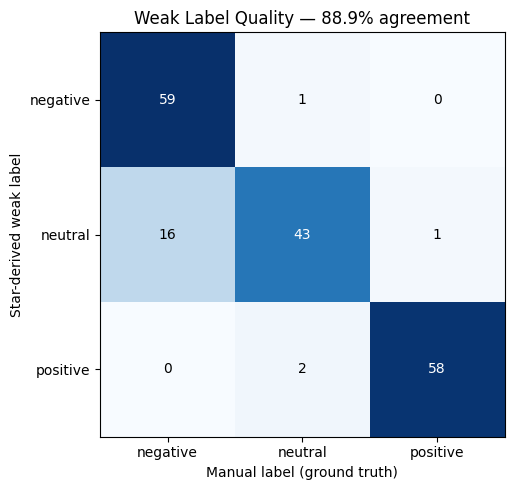

20 reviews where the star rating disagrees with the text:



,rating,sentiment_weak,manual_label,review_title,body_en
59,2,negative,neutral,Good,Okey type
62,3,neutral,negative,Chaise bureau,"It is not made of real leather, it is made of ..."
67,3,neutral,negative,Large pot burns and leaks. Single cup function...,I don't love this coffee maker. The burner is ...
72,3,neutral,negative,Not as advertised,I selected the model that is supposed to work ...
76,3,neutral,negative,Ridiculously Long!!,The shirts are way too long. They look ridicul...
80,3,neutral,negative,"Different colour, unexpected style differences",Not like picture
88,3,neutral,negative,Poor quality,"The picture looks like these are great shoes, ..."
90,3,neutral,negative,Calidad basica,"Poor quality, very plastic."
93,3,neutral,negative,So disappointing!,I bought these after hearing multiple social m...
99,3,neutral,negative,Great guitar but electronics defective,This guitar came apparently undamaged (shippin...


Predictions generated for all three models on 180 manually labelled reviews.
FINAL EVALUATION — against 180 manually labelled reviews


,model,accuracy,macro_f1,negative_f1,neutral_f1,positive_f1
3,Star rating baseline,0.889,0.887,0.874,0.811,0.975
1,LogReg (balanced),0.872,0.866,0.891,0.788,0.919
2,Transformer,0.678,0.623,0.736,0.312,0.820
0,VADER,0.533,0.456,0.564,0.156,0.648



Detailed report for the best model:
              precision    recall  f1-score   support

    negative      0.983     0.787     0.874        75
     neutral      0.717     0.935     0.811        46
    positive      0.967     0.983     0.975        59

    accuracy                          0.889       180
   macro avg      0.889     0.902     0.887       180
weighted avg      0.910     0.889     0.891       180



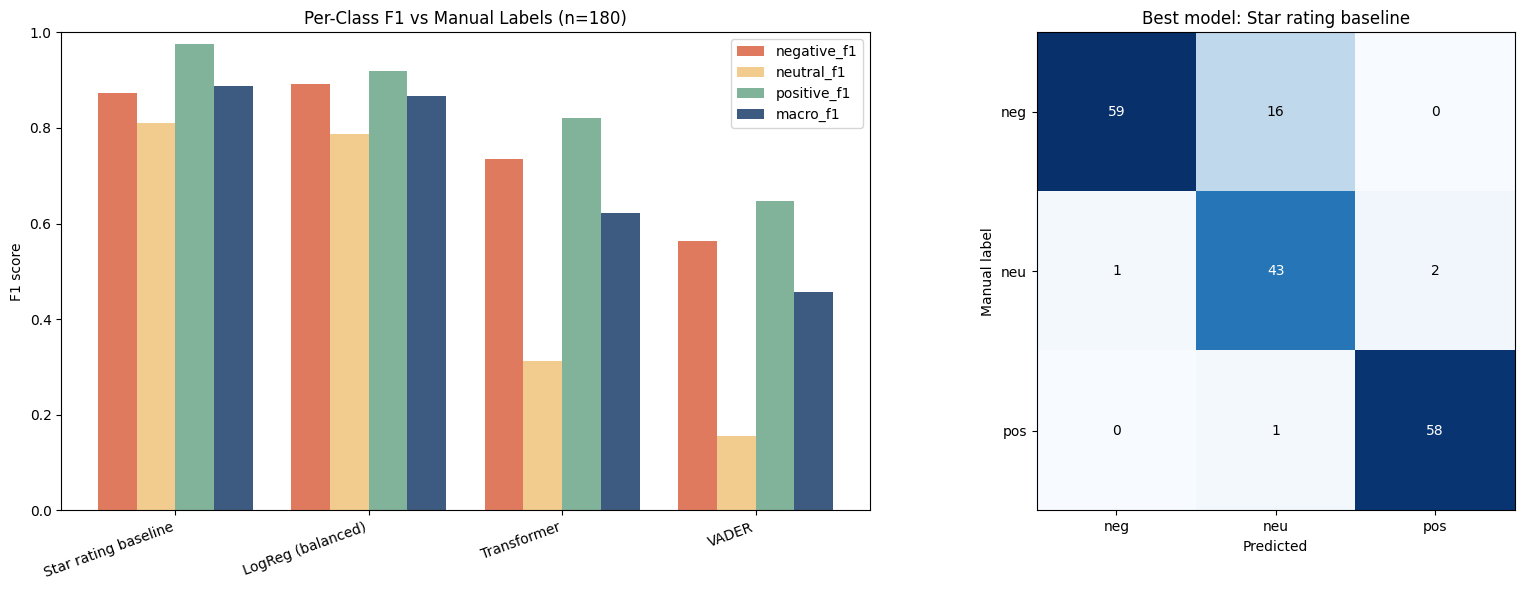

SENTIMENT SUMMARY BY CATEGORY


sentiment_final,category,negative,neutral,positive,total_reviews
0,phone stand,3.2,2.3,94.5,219
1,bluetooth speaker,3.1,2.6,94.3,229
2,water bottle,3.2,2.6,94.2,687
3,smartwatch,3.7,2.9,93.4,272
4,backpack,4.0,3.0,92.9,198
5,mechanical keyboard,1.9,5.3,92.8,207
6,kitchen knife set,4.2,3.5,92.3,601
7,notebook journal,3.7,4.5,91.8,623
8,webcam HD,4.8,3.5,91.7,229
9,desk lamp LED,3.7,5.0,91.3,564



Sample of product-level summary:


sentiment_final,asin,negative,neutral,positive,total_reviews
0,191445393X,0.0,0.0,100.0,13
1,8883707168,7.7,0.0,92.3,13
2,B00005IBX9,7.7,0.0,92.3,13
3,B00006IV0Q,15.4,0.0,84.6,13
4,B00009J580,15.4,23.1,61.5,13
5,B0006ZAU22,18.2,0.0,81.8,11
6,B000FDZJBM,15.4,7.7,76.9,13
7,B000GLN15O,15.4,7.7,76.9,13
8,B000OR2RNM,7.7,0.0,92.3,13
9,B000PRIPE6,0.0,23.1,76.9,13


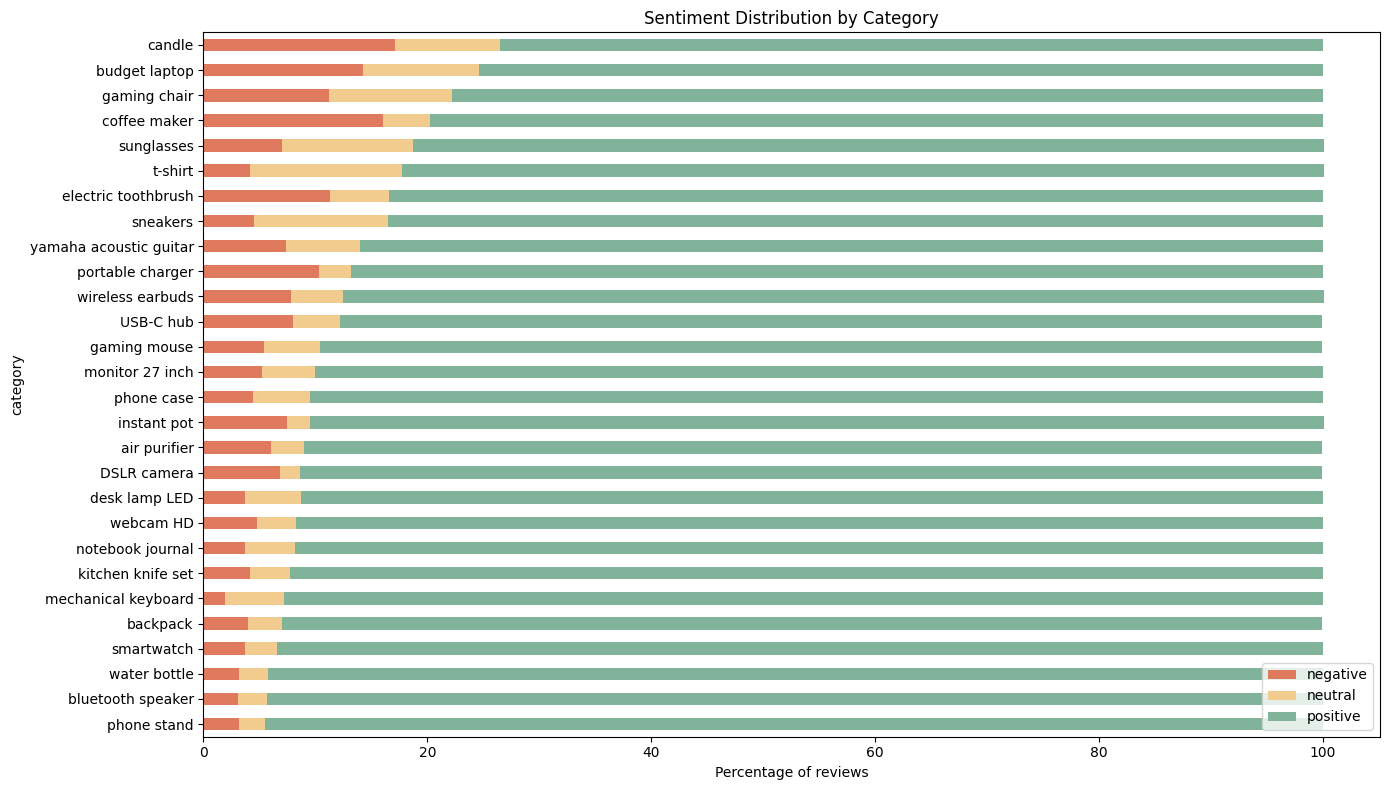

Saved Feature B artifacts:
  feature_b_all_reviews_scored.csv
  feature_b_category_sentiment.csv
  feature_b_evaluation.csv
  feature_b_product_sentiment.csv
  feature_b_sentiment_model.joblib
  feature_b_tfidf_vectorizer.joblib


In [5]:
# ============================================================
# CELL: Load manual labels and check agreement with star labels
# ============================================================
MANUAL_FILE = "/kaggle/input/datasets/ahsanrizvimeow/amazon-sentiment-manual-label-updated/sentiment_manual_labels_filled.csv"
manual = pd.read_csv(MANUAL_FILE)

print(f"Manual labels loaded: {len(manual)}")
display(manual["manual_label"].value_counts())

agreement = (manual["sentiment_weak"] == manual["manual_label"]).mean()
print(f"\nAgreement between star-derived and manual labels: {agreement*100:.1f}%")
print(f"Disagreements: {(manual['sentiment_weak'] != manual['manual_label']).sum()} of {len(manual)}")

print("\nWeak (star) label vs manual label:")
ct = pd.crosstab(manual["sentiment_weak"], manual["manual_label"],
                 rownames=["star-derived"], colnames=["manual"])
display(ct)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ct.values, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(3)); ax.set_yticklabels(ct.index)
ax.set_xlabel("Manual label (ground truth)")
ax.set_ylabel("Star-derived weak label")
ax.set_title(f"Weak Label Quality — {agreement*100:.1f}% agreement")
for i in range(3):
    for j in range(3):
        ax.text(j, i, ct.values[i, j], ha="center", va="center",
                color="white" if ct.values[i, j] > ct.values.max()/2 else "black")
plt.tight_layout()
plt.show()


# ============================================================
# CELL: Show the disagreements (most informative rows)
# ============================================================
disagreements = manual[manual["sentiment_weak"] != manual["manual_label"]]
print(f"{len(disagreements)} reviews where the star rating disagrees with the text:\n")
display(disagreements[["rating", "sentiment_weak", "manual_label",
                       "review_title", "body_en"]].head(25))


# ============================================================
# CELL: Run all three models on the manual test set
# ============================================================
manual["pred_vader"] = manual["body_en"].map(vader_sentiment)
manual["pred_lr"] = clf_bal.predict(vec.transform(manual["body_en"]))

bert_manual = sent_pipe(manual["body_en"].tolist(), batch_size=batch_size)
manual["pred_bert"] = [normalize_transformer_label(o["label"]) for o in bert_manual]

print("Predictions generated for all three models on 180 manually labelled reviews.")


# ============================================================
# CELL: Final evaluation against MANUAL labels
# ============================================================
final_results = []
model_cols = [("VADER", "pred_vader"),
              ("LogReg (balanced)", "pred_lr"),
              ("Transformer", "pred_bert"),
              ("Star rating baseline", "sentiment_weak")]

for name, col in model_cols:
    final_results.append({
        "model": name,
        "accuracy": accuracy_score(manual["manual_label"], manual[col]),
        "macro_f1": f1_score(manual["manual_label"], manual[col], average="macro"),
        "negative_f1": f1_score(manual["manual_label"], manual[col],
                                labels=["negative"], average=None, zero_division=0)[0],
        "neutral_f1": f1_score(manual["manual_label"], manual[col],
                               labels=["neutral"], average=None, zero_division=0)[0],
        "positive_f1": f1_score(manual["manual_label"], manual[col],
                                labels=["positive"], average=None, zero_division=0)[0],
    })

final_df = pd.DataFrame(final_results).sort_values("macro_f1", ascending=False).round(3)

print("=" * 80)
print("FINAL EVALUATION — against 180 manually labelled reviews")
print("=" * 80)
display(final_df)

print("\nDetailed report for the best model:")
best_col = dict(model_cols)[final_df.iloc[0]["model"]]
print(classification_report(manual["manual_label"], manual[best_col],
                            labels=["negative", "neutral", "positive"],
                            digits=3, zero_division=0))


# ============================================================
# CELL: Visualize final evaluation
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

x = np.arange(len(final_df))
width = 0.2
for i, (metric, color) in enumerate([("negative_f1", "#e07a5f"),
                                      ("neutral_f1", "#f2cc8f"),
                                      ("positive_f1", "#81b29a"),
                                      ("macro_f1", "#3d5a80")]):
    axes[0].bar(x + i*width, final_df[metric], width, label=metric, color=color)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(final_df["model"], rotation=20, ha="right")
axes[0].set_ylabel("F1 score")
axes[0].set_title("Per-Class F1 vs Manual Labels (n=180)")
axes[0].legend()
axes[0].set_ylim(0, 1)

cm = confusion_matrix(manual["manual_label"], manual[best_col],
                      labels=["negative", "neutral", "positive"])
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(["neg", "neu", "pos"])
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(["neg", "neu", "pos"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Manual label")
axes[1].set_title(f"Best model: {final_df.iloc[0]['model']}")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()


# ============================================================
# CELL: Apply best model to all reviews and build summaries
# ============================================================
rdf_clean["sentiment_final"] = clf_bal.predict(vec.transform(rdf_clean["body_en"]))

product_summary = (rdf_clean.groupby("asin")["sentiment_final"]
                   .value_counts(normalize=True).unstack(fill_value=0).mul(100).round(1))
product_summary["total_reviews"] = rdf_clean.groupby("asin").size()
product_summary = product_summary.reset_index()

category_summary = (rdf_clean.groupby("category")["sentiment_final"]
                    .value_counts(normalize=True).unstack(fill_value=0).mul(100).round(1))
category_summary["total_reviews"] = rdf_clean.groupby("category").size()
category_summary = category_summary.sort_values("positive", ascending=False).reset_index()

print("=" * 70)
print("SENTIMENT SUMMARY BY CATEGORY")
print("=" * 70)
display(category_summary)

print("\nSample of product-level summary:")
display(product_summary.head(10))

fig, ax = plt.subplots(figsize=(14, 8))
plot_data = category_summary.set_index("category")[["negative", "neutral", "positive"]]
plot_data.plot(kind="barh", stacked=True, ax=ax,
               color=["#e07a5f", "#f2cc8f", "#81b29a"])
ax.set_xlabel("Percentage of reviews")
ax.set_title("Sentiment Distribution by Category")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


# ============================================================
# CELL: Save Feature B artifacts
# ============================================================
import joblib

model_dir = "/kaggle/working/models"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(vec, f"{model_dir}/feature_b_tfidf_vectorizer.joblib")
joblib.dump(clf_bal, f"{model_dir}/feature_b_sentiment_model.joblib")

final_df.to_csv(f"{model_dir}/feature_b_evaluation.csv", index=False)
product_summary.to_csv(f"{model_dir}/feature_b_product_sentiment.csv", index=False)
category_summary.to_csv(f"{model_dir}/feature_b_category_sentiment.csv", index=False)
rdf_clean[["asin", "category", "rating", "review_title", "body_en",
           "sentiment_weak", "sentiment_final"]].to_csv(
    f"{model_dir}/feature_b_all_reviews_scored.csv", index=False)

print("Saved Feature B artifacts:")
for f in sorted(os.listdir(model_dir)):
    print(" ", f)

In [6]:
# ============================================================
# CELL: Leakage-Free Feature B Model Comparison
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. LOAD THE MANUAL GOLD SET
# ============================================================

MANUAL_FILE = "/kaggle/input/datasets/ahsanrizvimeow/amazon-sentiment-manual-label-updated/sentiment_manual_labels_filled.csv"

gold = pd.read_csv(MANUAL_FILE)

gold["manual_label"] = (
    gold["manual_label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

gold["body_en"] = (
    gold["body_en"]
    .fillna("")
    .astype(str)
)

gold = gold[
    gold["body_en"].str.strip().ne("") &
    gold["manual_label"].isin(
        ["negative", "neutral", "positive"]
    )
].copy()

gold = gold.reset_index(drop=True)

print("=" * 80)
print("MANUAL GOLD SET")
print("=" * 80)

print("Gold reviews:", len(gold))

display(
    gold["manual_label"]
    .value_counts()
    .rename_axis("manual_label")
    .reset_index(name="count")
)


# ============================================================
# 2. REMOVE GOLD REVIEWS FROM TRAINING DATA
# ============================================================

rdf_model = rdf_clean.copy()

rdf_model["body_en"] = (
    rdf_model["body_en"]
    .fillna("")
    .astype(str)
)

gold_texts = set(
    gold["body_en"]
    .str.strip()
)

train_df = rdf_model[
    ~rdf_model["body_en"]
    .str.strip()
    .isin(gold_texts)
].copy()

train_df = train_df.reset_index(drop=True)

print("\n" + "=" * 80)
print("LEAKAGE CHECK")
print("=" * 80)

print("Original usable reviews :", len(rdf_model))
print("Manual gold reviews     :", len(gold))
print("Training reviews        :", len(train_df))

print("\nTraining weak-label distribution:")

display(
    train_df["sentiment_weak"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)


# ============================================================
# 3. DEFINE MODELS
# ============================================================

models = {

    # --------------------------------------------------------
    # Model 1
    # --------------------------------------------------------

    "TF-IDF + Logistic Regression": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=30000,
                sublinear_tf=True
            )
        ),

        (
            "clf",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                C=1.0,
                random_state=42
            )
        )
    ]),


    # --------------------------------------------------------
    # Model 2
    # --------------------------------------------------------

    "TF-IDF + Linear SVM": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=30000,
                sublinear_tf=True
            )
        ),

        (
            "clf",
            LinearSVC(
                class_weight="balanced",
                C=1.0,
                random_state=42
            )
        )
    ]),


    # --------------------------------------------------------
    # Model 3
    # Word + character features
    # --------------------------------------------------------

    "Word + Character TF-IDF + SVM": Pipeline([
        (
            "features",
            FeatureUnion([
                (
                    "word",
                    TfidfVectorizer(
                        lowercase=True,
                        strip_accents="unicode",
                        stop_words="english",
                        ngram_range=(1, 2),
                        min_df=2,
                        max_features=25000,
                        sublinear_tf=True
                    )
                ),

                (
                    "char",
                    TfidfVectorizer(
                        analyzer="char_wb",
                        ngram_range=(3, 5),
                        min_df=3,
                        max_features=20000,
                        sublinear_tf=True
                    )
                )
            ])
        ),

        (
            "clf",
            LinearSVC(
                class_weight="balanced",
                C=1.0,
                random_state=42
            )
        )
    ]),


    # --------------------------------------------------------
    # Model 4
    # Larger n-gram range
    # --------------------------------------------------------

    "TF-IDF 1-3gram + Logistic Regression": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                stop_words="english",
                ngram_range=(1, 3),
                min_df=2,
                max_features=40000,
                sublinear_tf=True
            )
        ),

        (
            "clf",
            LogisticRegression(
                max_iter=2500,
                class_weight="balanced",
                C=2.0,
                random_state=42
            )
        )
    ]),


    # --------------------------------------------------------
    # Model 5
    # Stronger SVM regularization
    # --------------------------------------------------------

    "TF-IDF + SVM C=2": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=30000,
                sublinear_tf=True
            )
        ),

        (
            "clf",
            LinearSVC(
                class_weight="balanced",
                C=2.0,
                random_state=42
            )
        )
    ])
}


# ============================================================
# 4. TRAIN + EVALUATE
# ============================================================

X_train = train_df["body_en"]
y_train = train_df["sentiment_weak"]

X_gold = gold["body_en"]
y_gold = gold["manual_label"]

results = []
predictions = {}
trained_models = {}


for name, model in models.items():

    print("\n" + "=" * 80)
    print("TRAINING:", name)
    print("=" * 80)

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_gold)

    predictions[name] = pred
    trained_models[name] = model

    results.append({
        "model": name,

        "accuracy": accuracy_score(
            y_gold,
            pred
        ),

        "macro_f1": f1_score(
            y_gold,
            pred,
            average="macro"
        ),

        "negative_f1": f1_score(
            y_gold,
            pred,
            labels=["negative"],
            average=None,
            zero_division=0
        )[0],

        "neutral_f1": f1_score(
            y_gold,
            pred,
            labels=["neutral"],
            average=None,
            zero_division=0
        )[0],

        "positive_f1": f1_score(
            y_gold,
            pred,
            labels=["positive"],
            average=None,
            zero_division=0
        )[0],
    })

    print(
        classification_report(
            y_gold,
            pred,
            labels=[
                "negative",
                "neutral",
                "positive"
            ],
            digits=3,
            zero_division=0
        )
    )


# ============================================================
# 5. STAR RATING BASELINE
# ============================================================

star_pred = gold["sentiment_weak"]

results.append({
    "model": "Star Rating Baseline",

    "accuracy": accuracy_score(
        y_gold,
        star_pred
    ),

    "macro_f1": f1_score(
        y_gold,
        star_pred,
        average="macro"
    ),

    "negative_f1": f1_score(
        y_gold,
        star_pred,
        labels=["negative"],
        average=None,
        zero_division=0
    )[0],

    "neutral_f1": f1_score(
        y_gold,
        star_pred,
        labels=["neutral"],
        average=None,
        zero_division=0
    )[0],

    "positive_f1": f1_score(
        y_gold,
        star_pred,
        labels=["positive"],
        average=None,
        zero_division=0
    )[0]
})


# ============================================================
# 6. FINAL COMPARISON TABLE
# ============================================================

comparison_df = (
    pd.DataFrame(results)
    .sort_values(
        ["macro_f1", "negative_f1"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("LEAKAGE-FREE FINAL COMPARISON")
print("=" * 80)

print(
    f"Evaluation set: {len(gold)} manually labelled reviews"
)

display(
    comparison_df.round(3)
)


# ============================================================
# 7. BEST MODEL
# ============================================================

best_name = comparison_df.iloc[0]["model"]

print("\n" + "=" * 80)
print("BEST OVERALL MODEL")
print("=" * 80)

print(best_name)

if best_name == "Star Rating Baseline":

    best_pred = star_pred
    best_model = None

else:

    best_pred = predictions[best_name]
    best_model = trained_models[best_name]


# ============================================================
# 8. CONFUSION MATRIX
# ============================================================

labels = [
    "negative",
    "neutral",
    "positive"
]

cm = confusion_matrix(
    y_gold,
    best_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Negative",
        "Actual Neutral",
        "Actual Positive"
    ],
    columns=[
        "Pred Negative",
        "Pred Neutral",
        "Pred Positive"
    ]
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

display(cm_df)


# ============================================================
# 9. DETAILED BEST-MODEL REPORT
# ============================================================

print("\n" + "=" * 80)
print("BEST MODEL CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_gold,
        best_pred,
        labels=labels,
        digits=3,
        zero_division=0
    )
)


# ============================================================
# 10. FIND THE BEST TEXT MODEL
# ============================================================

text_comparison = comparison_df[
    comparison_df["model"] != "Star Rating Baseline"
].copy()

best_text_name = text_comparison.iloc[0]["model"]

best_text_model = trained_models[
    best_text_name
]

best_text_pred = predictions[
    best_text_name
]

print("\n" + "=" * 80)
print("BEST TEXT MODEL")
print("=" * 80)

print(best_text_name)


# ============================================================
# 11. ERROR ANALYSIS
# ============================================================

error_df = gold.copy()

error_df["prediction"] = best_text_pred

error_df["correct"] = (
    error_df["manual_label"] ==
    error_df["prediction"]
)

errors = error_df[
    ~error_df["correct"]
].copy()

print("\n" + "=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)

print("Best text model:", best_text_name)
print("Total errors:", len(errors))

display(
    errors[
        [
            "rating",
            "sentiment_weak",
            "manual_label",
            "prediction",
            "review_title",
            "body_en"
        ]
    ].head(50)
)


# ============================================================
# 12. NEGATIVE CLASS ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("NEGATIVE REVIEW ANALYSIS")
print("=" * 80)

negative_reviews = error_df[
    error_df["manual_label"] == "negative"
]

print(
    "Actual negative reviews:",
    len(negative_reviews)
)

display(
    negative_reviews[
        [
            "rating",
            "sentiment_weak",
            "manual_label",
            "prediction",
            "review_title",
            "body_en"
        ]
    ]
)


# ============================================================
# 13. NEUTRAL CLASS ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("NEUTRAL REVIEW ANALYSIS")
print("=" * 80)

neutral_reviews = error_df[
    error_df["manual_label"] == "neutral"
]

print(
    "Actual neutral reviews:",
    len(neutral_reviews)
)

display(
    neutral_reviews[
        [
            "rating",
            "sentiment_weak",
            "manual_label",
            "prediction",
            "review_title",
            "body_en"
        ]
    ]
)


# ============================================================
# 14. COMPARE STAR BASELINE VS BEST TEXT MODEL
# ============================================================

star_correct = (
    gold["manual_label"] ==
    gold["sentiment_weak"]
)

text_correct = (
    gold["manual_label"] ==
    best_text_pred
)

comparison_cases = gold[
    [
        "asin",
        "rating",
        "manual_label",
        "sentiment_weak"
    ]
].copy()

comparison_cases["text_prediction"] = best_text_pred

comparison_cases["star_correct"] = star_correct
comparison_cases["text_correct"] = text_correct

print("\n" + "=" * 80)
print("STAR BASELINE VS BEST TEXT MODEL")
print("=" * 80)

print(
    "Cases text model gets right but star baseline gets wrong:",
    ((text_correct) & (~star_correct)).sum()
)

print(
    "Cases star baseline gets right but text model gets wrong:",
    ((star_correct) & (~text_correct)).sum()
)

print(
    "Cases both get right:",
    ((star_correct) & (text_correct)).sum()
)

print(
    "Cases both get wrong:",
    ((~star_correct) & (~text_correct)).sum()
)

print("\nText model wins:")
display(
    comparison_cases[
        text_correct & ~star_correct
    ][
        [
            "asin",
            "rating",
            "manual_label",
            "sentiment_weak",
            "text_prediction"
        ]
    ]
)

print("\nStar baseline wins:")
display(
    comparison_cases[
        star_correct & ~text_correct
    ][
        [
            "asin",
            "rating",
            "manual_label",
            "sentiment_weak",
            "text_prediction"
        ]
    ]
)


# ============================================================
# 15. STORE BEST MODEL IN MEMORY
# ============================================================

print("\n" + "=" * 80)
print("READY")
print("=" * 80)

print("Best text model:", best_text_name)
print("Object name: best_text_model")

MANUAL GOLD SET
Gold reviews: 180


,manual_label,count
0,negative,75
1,positive,59
2,neutral,46



LEAKAGE CHECK
Original usable reviews : 11282
Manual gold reviews     : 180
Training reviews        : 11085

Training weak-label distribution:


,label,count
0,positive,10207
1,negative,509
2,neutral,369



TRAINING: TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    negative      0.780     0.613     0.687        75
     neutral      0.458     0.239     0.314        46
    positive      0.588     0.966     0.731        59

    accuracy                          0.633       180
   macro avg      0.609     0.606     0.577       180
weighted avg      0.635     0.633     0.606       180


TRAINING: TF-IDF + Linear SVM
              precision    recall  f1-score   support

    negative      0.881     0.493     0.632        75
     neutral      0.333     0.022     0.041        46
    positive      0.437     1.000     0.608        59

    accuracy                          0.539       180
   macro avg      0.550     0.505     0.427       180
weighted avg      0.595     0.539     0.473       180


TRAINING: Word + Character TF-IDF + SVM
              precision    recall  f1-score   support

    negative      0.864     0.507     0.639        75
     neutral     

...


STAR BASELINE VS BEST TEXT MODEL
Cases text model gets right but star baseline gets wrong: 10
Cases star baseline gets right but text model gets wrong: 56
Cases both get right: 104
Cases both get wrong: 10

Text model wins:


,asin,rating,manual_label,sentiment_weak,text_prediction
62,B08B12P6CS,3,negative,neutral,negative
72,B0FH25Z9W3,3,negative,neutral,negative
76,B0DS279YBH,3,negative,neutral,negative
80,B07L4JCG7T,3,negative,neutral,negative
90,B0CWRCCFTM,3,negative,neutral,negative
99,B0BHX8JVNH,3,negative,neutral,negative
100,B0F72ZCGWB,3,negative,neutral,negative
109,B0F28L2J8G,3,negative,neutral,negative
117,B08VJ25PL1,3,negative,neutral,negative
144,B0GZZVM9DX,5,neutral,positive,neutral



Star baseline wins:


,asin,rating,manual_label,sentiment_weak,text_prediction
2,B002YX0GAA,1,negative,negative,positive
3,B08FJ678YK,1,negative,negative,positive
4,B0006ZAU22,2,negative,negative,positive
11,B0C4BZ28PG,2,negative,negative,positive
14,B0GF1GYKW5,1,negative,negative,positive
24,B0G11F8FHR,1,negative,negative,neutral
26,B0FPRHR6XZ,1,negative,negative,neutral
27,B0BKSKCYX7,2,negative,negative,neutral
30,B09JYJ6JKH,2,negative,negative,neutral
32,B0F2G217VL,1,negative,negative,positive



READY
Best text model: TF-IDF + Logistic Regression
Object name: best_text_model


In [7]:
import joblib, os
model_dir = "/kaggle/working/models"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(best_text_model, f"{model_dir}/feature_b_sentiment_model.joblib")
comparison_df.to_csv(f"{model_dir}/feature_b_evaluation.csv", index=False)

rdf_clean["sentiment_final"] = rdf_clean["sentiment_weak"]
product_summary = (rdf_clean.groupby("asin")["sentiment_final"]
                   .value_counts(normalize=True).unstack(fill_value=0).mul(100).round(1))
product_summary["total_reviews"] = rdf_clean.groupby("asin").size()
product_summary.reset_index().to_csv(f"{model_dir}/feature_b_product_sentiment.csv", index=False)

category_summary = (rdf_clean.groupby("category")["sentiment_final"]
                    .value_counts(normalize=True).unstack(fill_value=0).mul(100).round(1))
category_summary["total_reviews"] = rdf_clean.groupby("category").size()
category_summary.reset_index().to_csv(f"{model_dir}/feature_b_category_sentiment.csv", index=False)

print("Saved:", os.listdir(model_dir))

Saved: ['feature_b_product_sentiment.csv', 'feature_b_category_sentiment.csv', 'feature_b_tfidf_vectorizer.joblib', 'feature_b_evaluation.csv', 'feature_b_all_reviews_scored.csv', 'feature_b_sentiment_model.joblib']
